In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

label_col = "GPT-IPTC-label"

train_df = pd.read_json("../data/el_train.jsonl", lines=True)
val_df = pd.read_json("../data/el_val.jsonl", lines=True)

baseline = make_pipeline(
    TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        strip_accents="unicode",
    ),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)

baseline.fit(train_df["text_clean"], train_df[label_col])
val_pred = baseline.predict(val_df["text_clean"])
print("Έτοιμο")

Έτοιμο


In [2]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", round(accuracy_score(val_df[label_col], val_pred), 3))
print("Macro-F1:", round(f1_score(val_df[label_col], val_pred, average="macro"), 3))
print()
print(classification_report(val_df[label_col], val_pred, zero_division=0))

Accuracy: 0.737
Macro-F1: 0.67

                                           precision    recall  f1-score   support

   arts, culture, entertainment and media       0.74      0.76      0.75        79
                  conflict, war and peace       0.50      0.50      0.50        26
                   crime, law and justice       0.79      0.79      0.79        63
disaster, accident and emergency incident       0.76      0.53      0.62        36
            economy, business and finance       0.69      0.71      0.70        99
                                education       0.65      0.84      0.73        31
                              environment       0.76      0.72      0.74        18
                                   health       0.78      0.92      0.85        39
                           human interest       0.59      0.63      0.61        62
                                   labour       0.74      0.81      0.77        21
                    lifestyle and leisure       0.00  

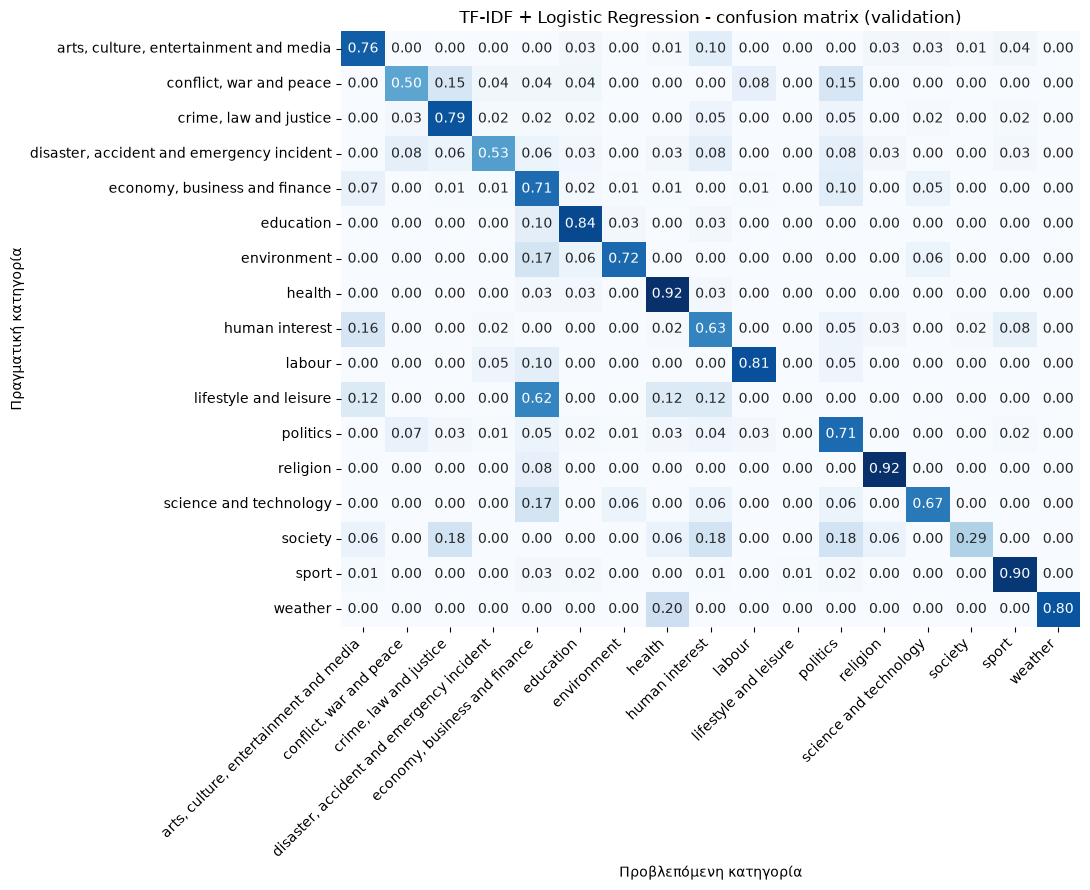

In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = sorted(train_df[label_col].unique())
cm = confusion_matrix(val_df[label_col], val_pred, labels=labels, normalize="true")

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Προβλεπόμενη κατηγορία")
plt.ylabel("Πραγματική κατηγορία")
plt.title("TF-IDF + Logistic Regression - confusion matrix (validation)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

os.makedirs("../docs", exist_ok=True)
plt.savefig("../docs/baseline_confusion_matrix.png", dpi=150)
plt.show()